In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import dataloader as dl

Configration

In [2]:
Learning_rate = 0.01
no_epochs = 30

# Logistic Regression Implementation

In [3]:
torch.manual_seed(42)

class Logistic_Regression_from_scratch():
    def __init__(self):
        self.w = torch.randn(28*28, requires_grad=True)

        self.b = torch.zeros(1, requires_grad=True)

        self.validation_losses = []
        self.training_losses = []
        self.validation_accuracies = []
        self.training_accuracies = []

    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))

    def bce_loss(self,y_true, y_pred):
        epsilon = 1e-7
        loss = - (y_true * torch.log(y_pred + epsilon) + (1 - y_true) * torch.log(1 - y_pred + epsilon))
        return torch.mean(loss)

    def forward_pass(self, x):
        output =  x @ self.w + self.b
        y_pred = self.sigmoid(output)
        return y_pred

    def train(self, learning_rate, no_epochs, train_loader, val_loader):
        for epoch in range(no_epochs):
            train_loss = 0
            val_losses = 0
            train_accuracy = 0
            val_accuracy = 0

            for data, target in train_loader:
                target = target.float()

                y_pred = self.forward_pass(data)
                loss = self.bce_loss(target, y_pred)


                train_accuracy += self.calculate_accuracy(target, y_pred)

                train_loss += loss.item()

                loss.backward()

                with torch.no_grad():
                    self.w -= learning_rate * self.w.grad
                    self.b  -= learning_rate * self.b.grad

                    self.w.grad.zero_()
                    self.b.grad.zero_()



            with torch.no_grad():
                for val_data, val_target in val_loader:
                    val_target = val_target.float()
                    val_pred = self.forward_pass(val_data)

                    val_accuracy += self.calculate_accuracy(val_target, val_pred)

                    val_loss = self.bce_loss(val_target, val_pred)
                    val_losses += val_loss.item()


            self.training_accuracies.append(train_accuracy / len(train_loader))
            self.validation_accuracies.append(val_accuracy / len(val_loader))
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_losses / len(val_loader)


            self.training_losses.append(avg_train_loss)
            self.validation_losses.append(avg_val_loss)

            print(f'Epoch {epoch+1}/{no_epochs}')
            print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {self.training_accuracies[epoch]:.2f}%')
            print(f'  Val Loss: {avg_val_loss:.4f} | Val Acc: {self.validation_accuracies[epoch]:.2f}%')



    def predict(self, x):
        with torch.no_grad():
            y_pred = self.forward_pass(x)
            predicted_labels = (y_pred > 0.5).float()
        return predicted_labels

    def calculate_accuracy(self, y_true, y_pred):
        predicted_labels = (y_pred > 0.5).float()
        return (predicted_labels == y_true).sum().item() / y_true.shape[0] *100

In [4]:
logisticRegression = Logistic_Regression_from_scratch()
loader=dl.build_loader(64)
logisticRegression.train(Learning_rate, no_epochs, loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'])

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 2.0716 | Train Acc: 56.86%
  Val Loss: 0.6116 | Val Acc: 78.48%
Epoch 2/30
  Train Loss: 0.4199 | Train Acc: 85.72%
  Val Loss: 0.2864 | Val Acc: 91.34%
Epoch 3/30
  Train Loss: 0.2276 | Train Acc: 

## Training vs Validation Loss

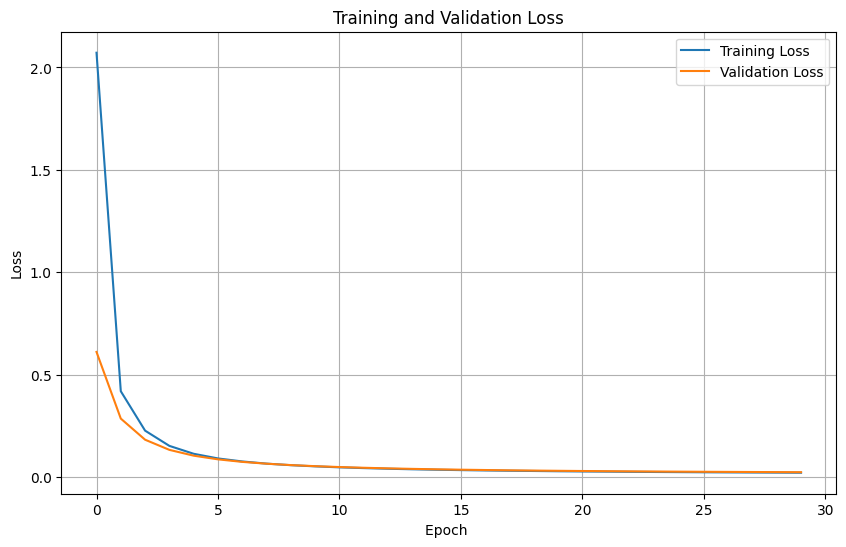

In [5]:

def plot_loss(text):
    plt.figure(figsize=(10, 6))
    plt.plot(logisticRegression.training_losses, label='Training Loss')
    plt.plot(logisticRegression.validation_losses, label='Validation Loss')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_loss('')

## Target vs value accuracy

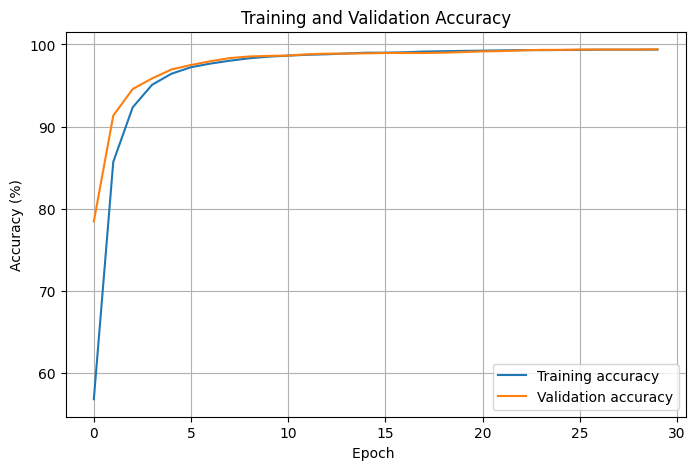

In [6]:

def plot_acc(text):
    plt.figure(figsize=(8, 5))
    plt.plot(logisticRegression.training_accuracies, label='Training accuracy')
    plt.plot(logisticRegression.validation_accuracies, label='Validation accuracy')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_acc('')



### Learing curve with error bars

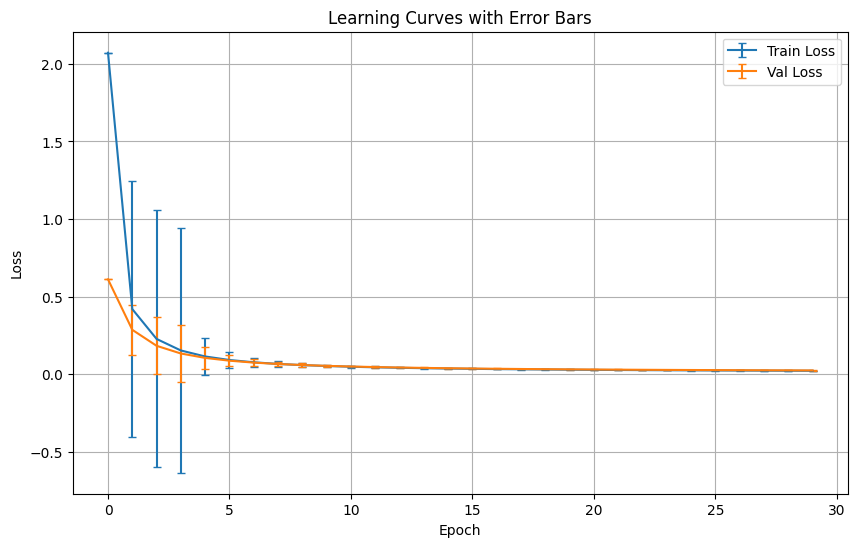

In [7]:
window = 3
train_std = [np.std(logisticRegression.training_losses[max(0,i-window):i+1]) for i in range(len(logisticRegression.training_losses))]
val_std = [np.std(logisticRegression.validation_losses[max(0,i-window):i+1]) for i in range(len(logisticRegression.validation_losses))]

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(logisticRegression.training_losses)), logisticRegression.training_losses, yerr=train_std, label='Train Loss', capsize=3)
plt.errorbar(range(len(logisticRegression.validation_losses)), logisticRegression.validation_losses, yerr=val_std, label='Val Loss', capsize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves with Error Bars')
plt.legend()
plt.grid(True)
plt.show()

### converge Analysis

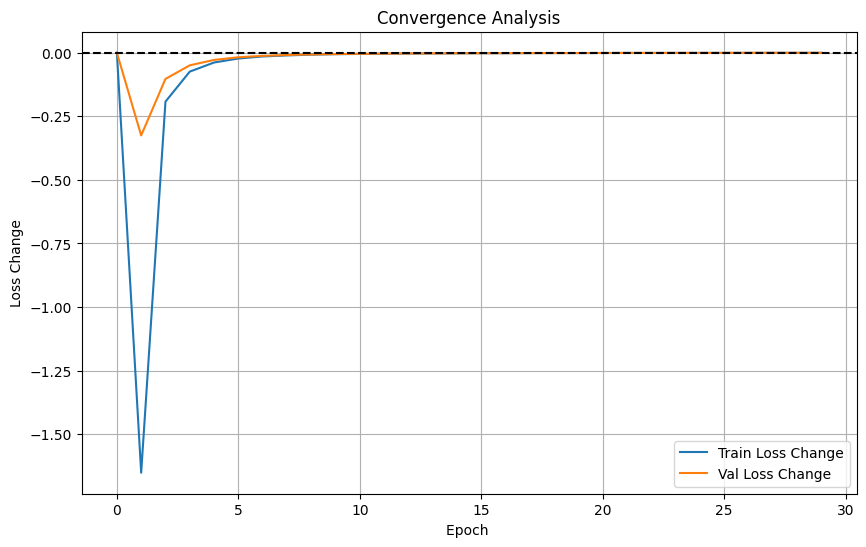

In [8]:
def plot_converge(text):
    train_change = [0] + [logisticRegression.training_losses[i] - logisticRegression.training_losses[i-1] for i in range(1, len(logisticRegression.training_losses))]
    val_change = [0] + [logisticRegression.validation_losses[i] - logisticRegression.validation_losses[i-1] for i in range(1, len(logisticRegression.validation_losses))]

    plt.figure(figsize=(10, 6))
    plt.plot(train_change, label='Train Loss Change')
    plt.plot(val_change, label='Val Loss Change')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss Change')
    plt.title('Convergence Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_converge('')

## Test the Model

In [ ]:
def test_model():
    accuracy = 0
    targets = []
    predictions = []
    with torch.no_grad():
        for data, target in loader["test_loader_linear_filtered"]:
            target = target.float()

            prediction = logisticRegression.predict(data)
            accuracy += logisticRegression.calculate_accuracy(target, prediction)
            targets.extend(target.numpy())
            predictions.extend(prediction)

    test_accuracy = accuracy / len(loader["test_loader_linear_filtered"])

    print(f"Average Test Accuracy over all batches: {test_accuracy:.2f}%")

    matrix = confusion_matrix(np.array(targets), np.array(predictions))
    print("Confusion Matrix:")
    print(matrix)
test_model()

Average Test Accuracy over all batches: 99.26%
Confusion Matrix:
[[1169   16]
 [   3 1346]]


## Define hyperparameters




In [10]:
learning_rates = [0.001,0.01,0.1,1]
batch_sizes = [16,32,64,128]

Testing different learning rates with fixed batch size (64):
Training with Learning Rate: 0.001, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.7630 | Train Acc: 85.91%
  Val Loss: 0.6897 | Val Acc: 86.05%
Epoch 2/30
  Train Los

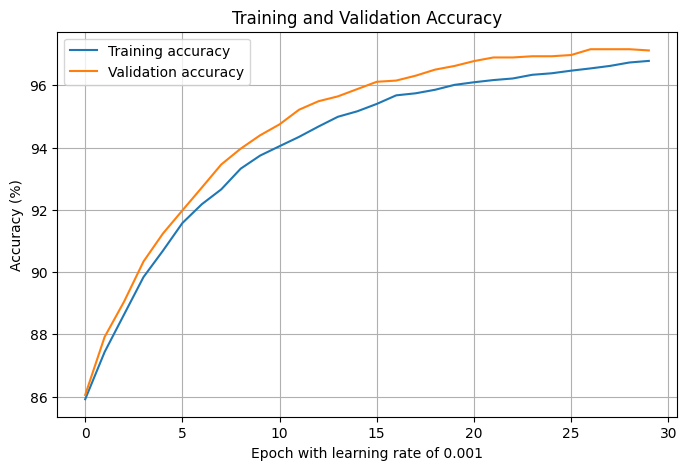

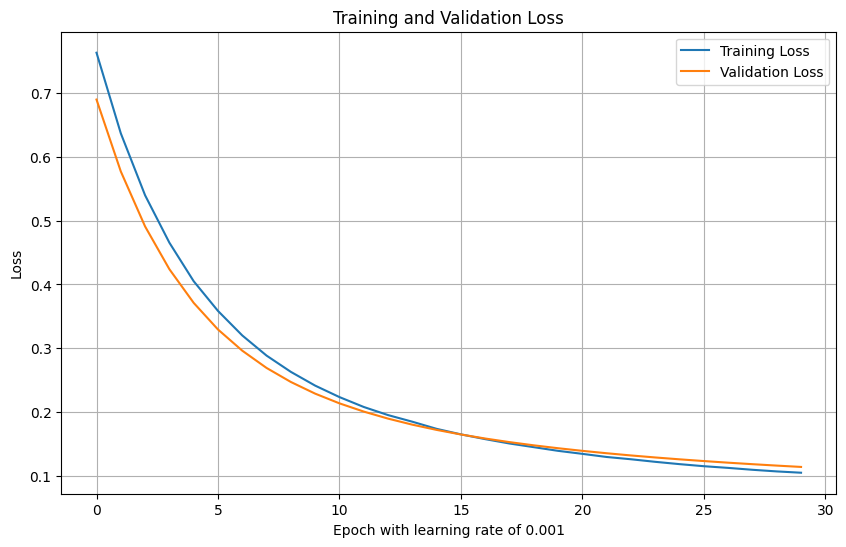

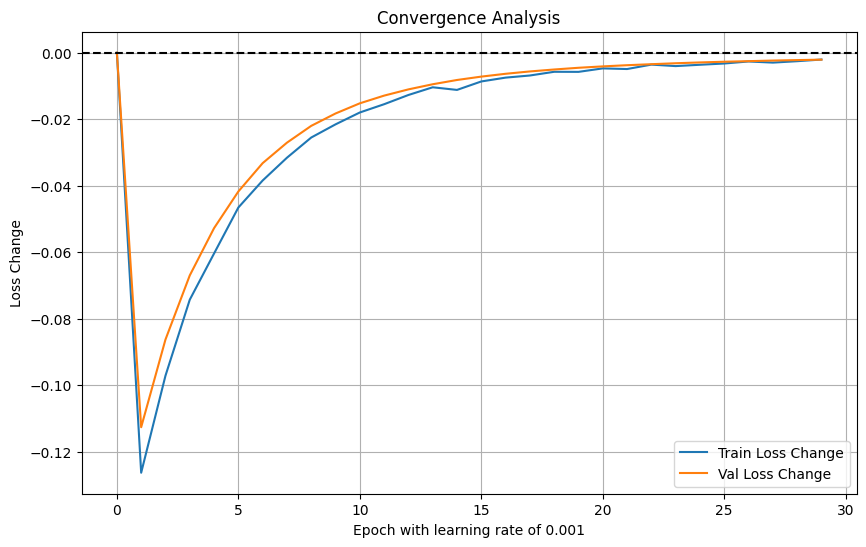

Training with Learning Rate: 0.01, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.2446 | Train Acc: 92.52%
  Val Loss: 0.1761 | Val Acc: 94.51%
Epoch 2/30
  Train Loss: 0.1604 | Train Acc: 95.02%
  Val Loss: 0.1251 | Val Acc: 95

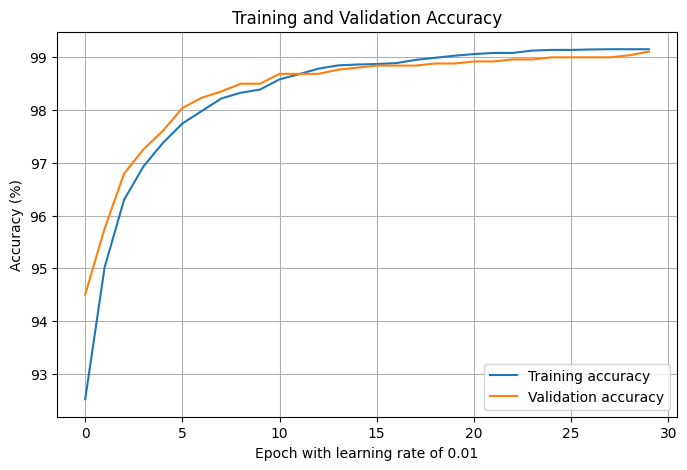

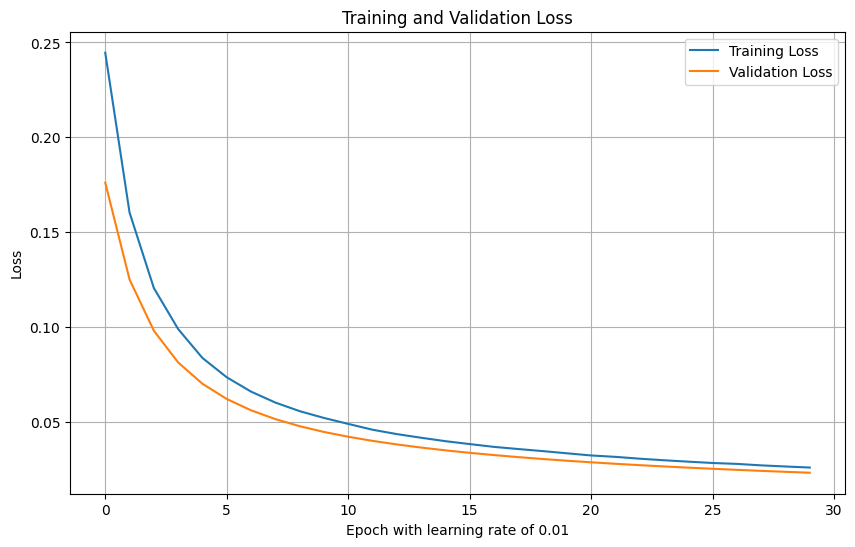

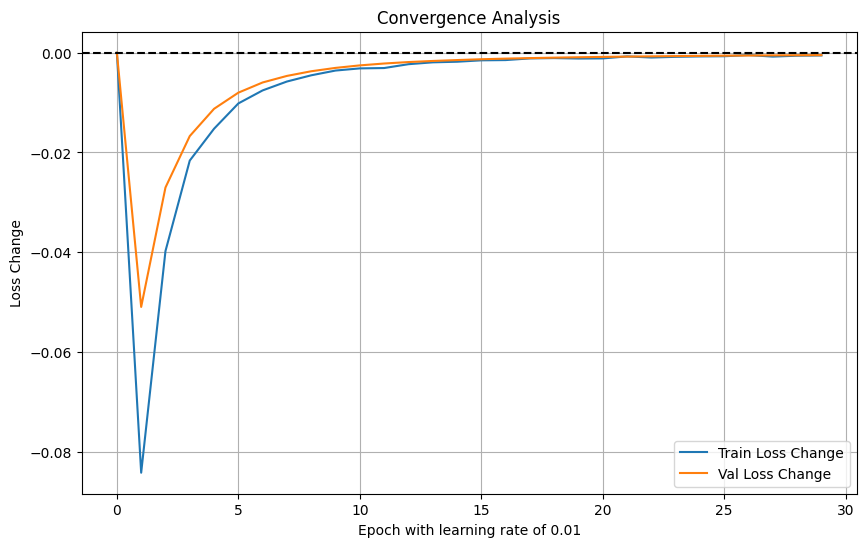

Training with Learning Rate: 0.1, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.2110 | Train Acc: 93.09%
  Val Loss: 0.0606 | Val Acc: 98.17%
Epoch 2/30
  Train Loss: 0.0472 | Train Acc: 98.82%
  Val Loss: 0.0329 | Val Acc: 99.

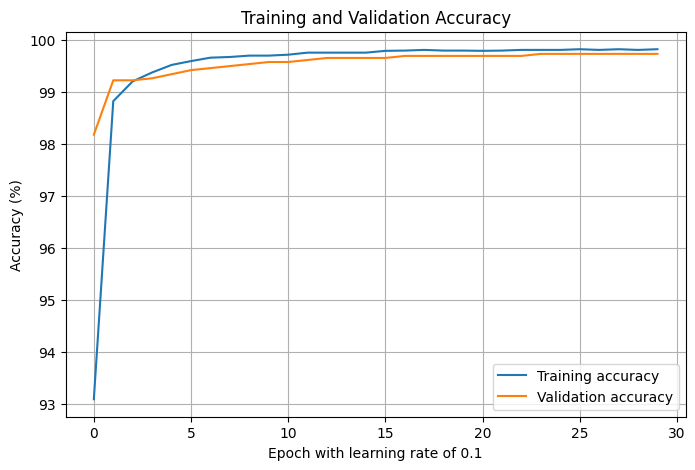

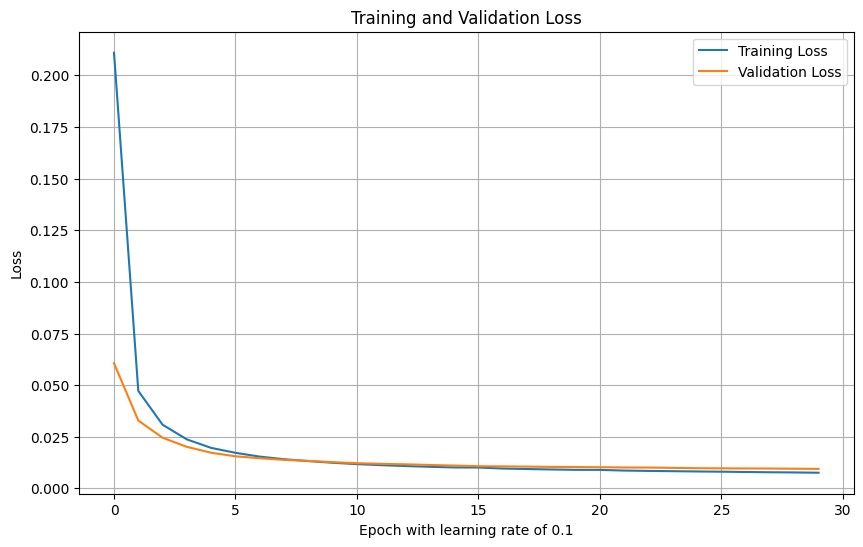

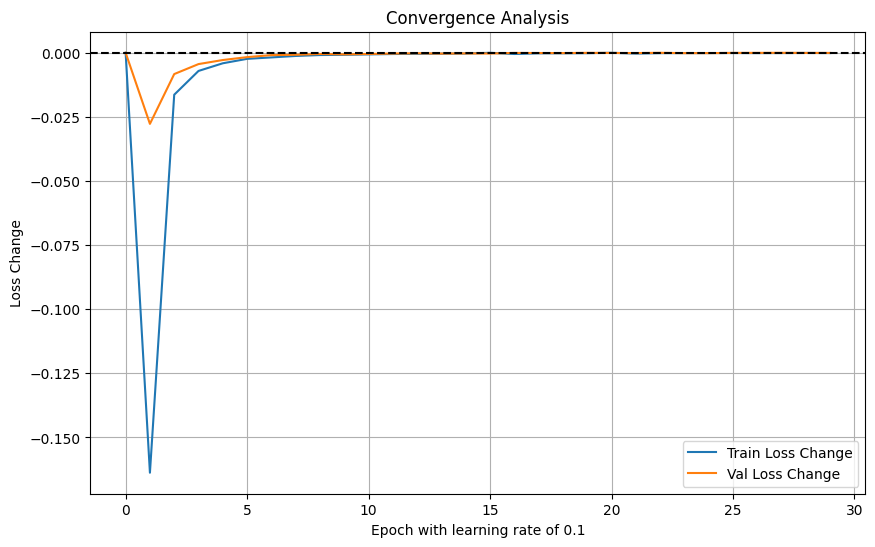

Training with Learning Rate: 1, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.0585 | Train Acc: 98.35%
  Val Loss: 0.0240 | Val Acc: 99.34%
Epoch 2/30
  Train Loss: 0.0149 | Train Acc: 99.58%
  Val Loss: 0.0163 | Val Acc: 99.49

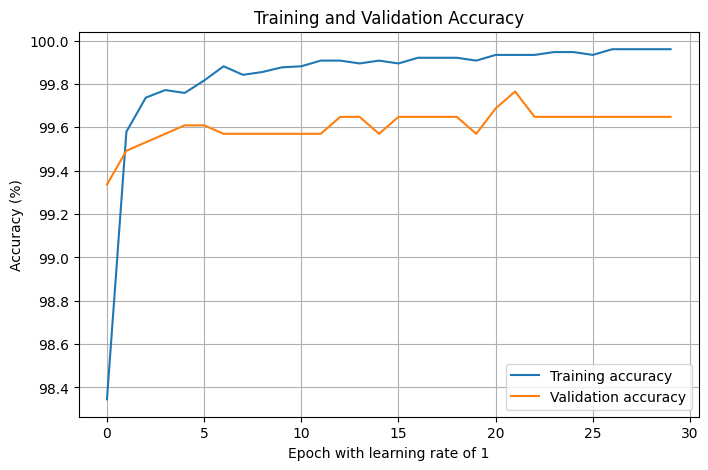

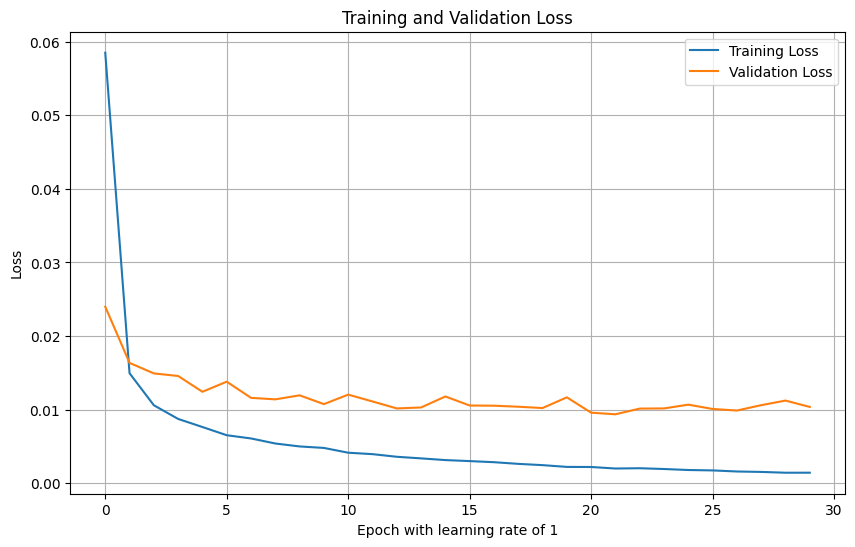

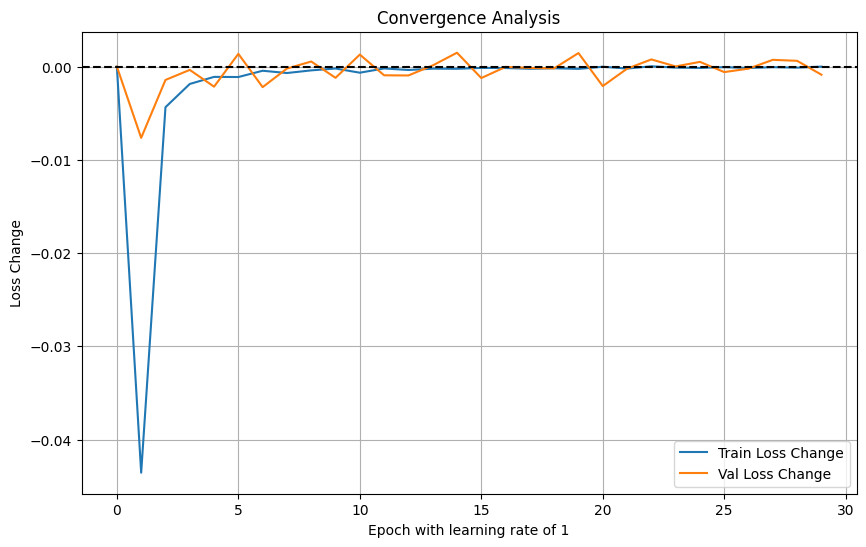

In [11]:
results_lr = []
fixed_batch_size = 64
print("Testing different learning rates with fixed batch size (64):")
best_val_accuracy_lr = 0
best_lr=None

for lr in learning_rates:
    print(f"Training with Learning Rate: {lr}, Batch Size: {fixed_batch_size}")

    logisticRegression = Logistic_Regression_from_scratch()
    loader = dl.build_loader(fixed_batch_size)

    logisticRegression.train(lr, no_epochs, loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'])
    plot_acc(f'with learning rate of {lr}')
    plot_loss(f'with learning rate of {lr}')
    plot_converge(f'with learning rate of {lr}')

    current_best_val_accuracy = max(logisticRegression.validation_accuracies)
    if current_best_val_accuracy > best_val_accuracy_lr:
        best_val_accuracy_lr = current_best_val_accuracy
        best_lr=lr


### getting the test accuracy for the best learning rate

In [12]:
print(f"the best learning rate {best_lr}")
logisticRegression = Logistic_Regression_from_scratch()
loader = dl.build_loader(fixed_batch_size)
logisticRegression.train(best_lr, no_epochs, loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'])
test_model()

the best learning rate 1
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.0473 | Train Acc: 98.58%
  Val Loss: 0.0093 | Val Acc: 99.73%
Epoch 2/30
  Train Loss: 0.0117 | Train Acc: 99.63%
  Val Loss: 0.0064 | Val Acc: 99.77%
Epoch 3/30
  Train L

### getting the best batch size


Testing different batch sizes with fixed learning rate (0.01):
Training with Learning Rate: 0.01, Batch Size: 16
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.5313 | Train Acc: 84.85%
  Val Loss: 0.1181 | Val Acc: 96.07%
Epoch 2/30
  Train L

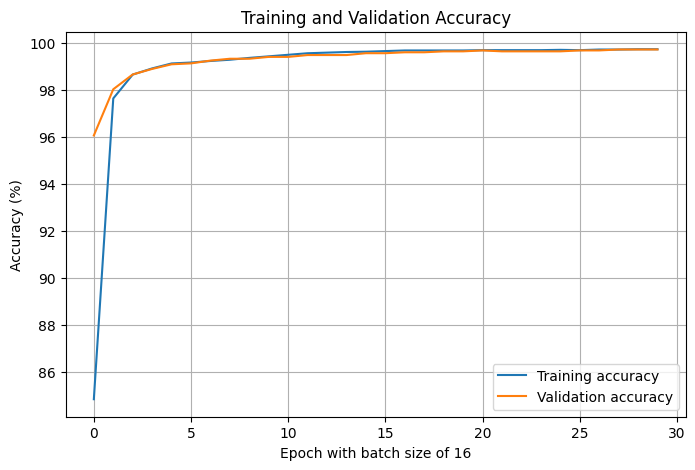

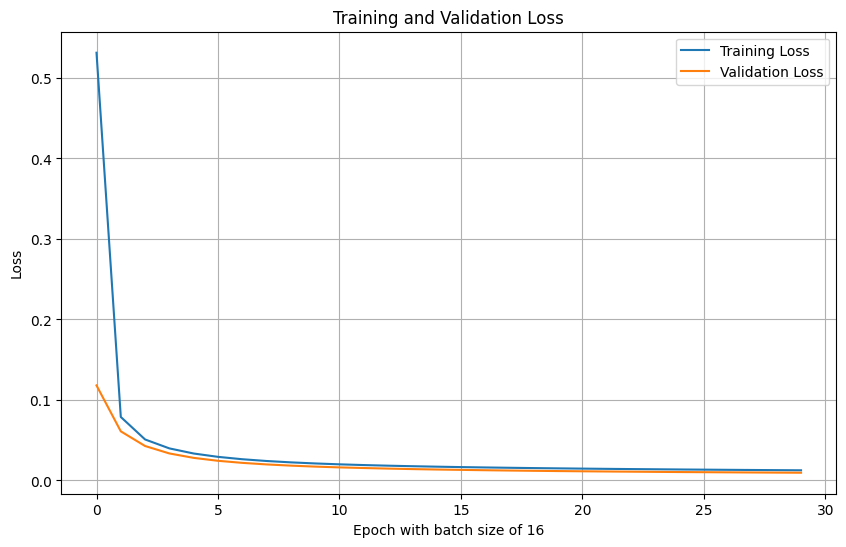

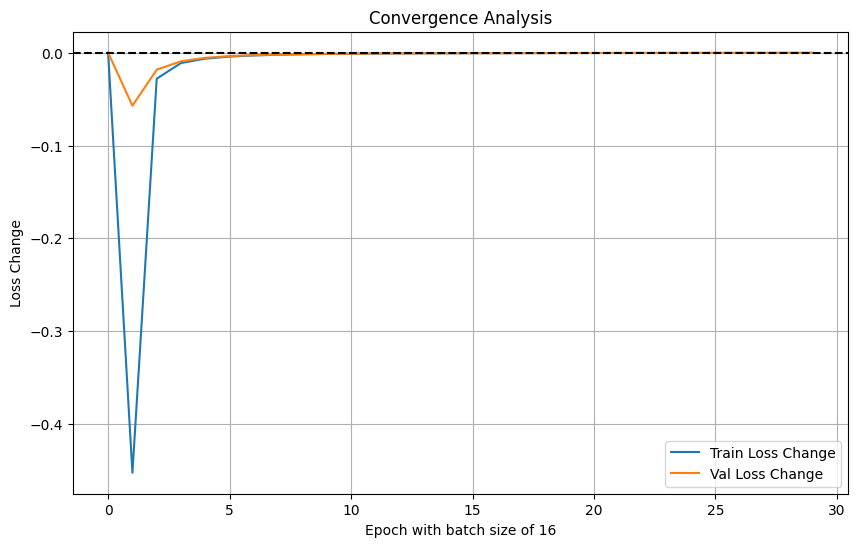

Training with Learning Rate: 0.01, Batch Size: 32
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.8871 | Train Acc: 78.18%
  Val Loss: 0.3016 | Val Acc: 90.70%
Epoch 2/30
  Train Loss: 0.2277 | Train Acc: 92.48%
  Val Loss: 0.1389 | Val Acc: 95

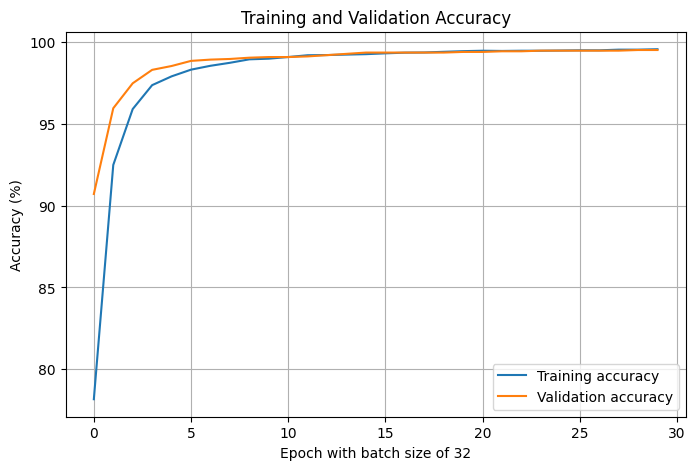

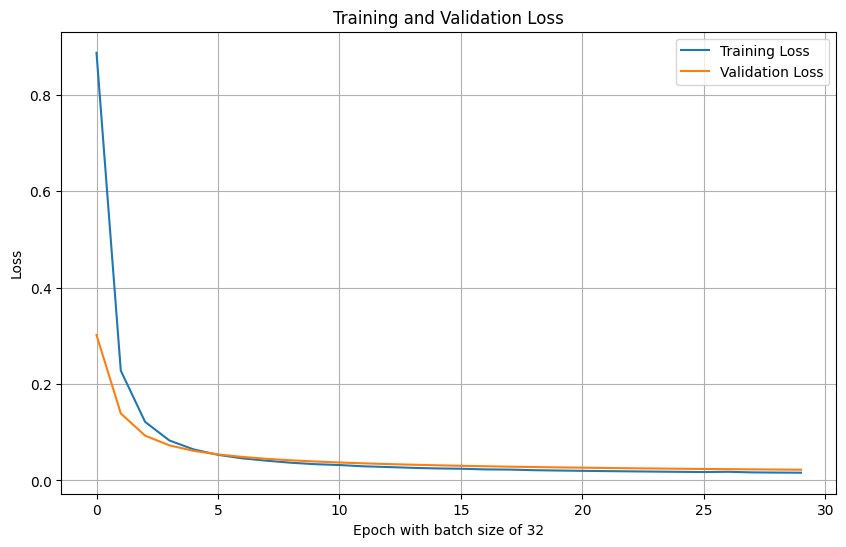

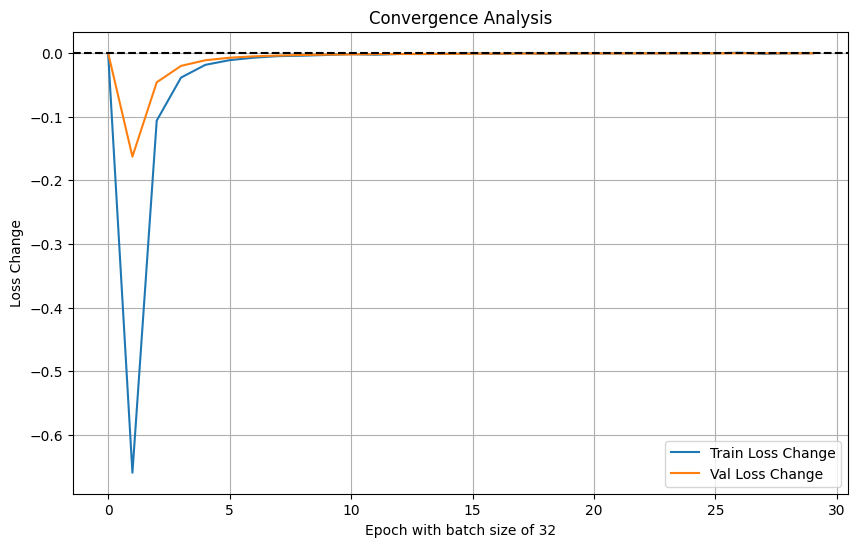

Training with Learning Rate: 0.01, Batch Size: 64
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 1.1021 | Train Acc: 72.96%
  Val Loss: 0.5450 | Val Acc: 84.21%
Epoch 2/30
  Train Loss: 0.4153 | Train Acc: 87.99%
  Val Loss: 0.3358 | Val Acc: 91

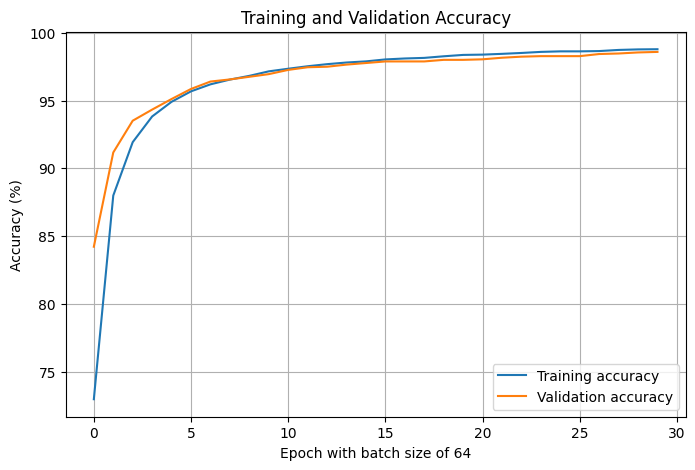

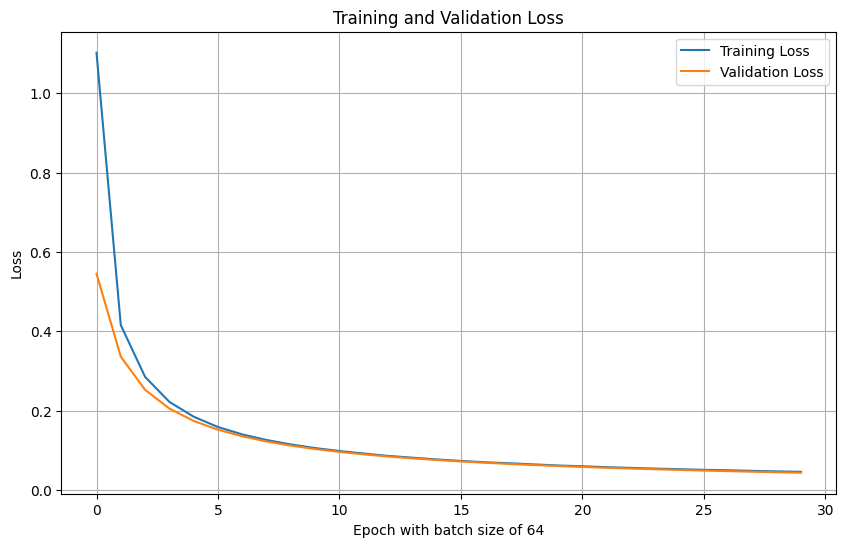

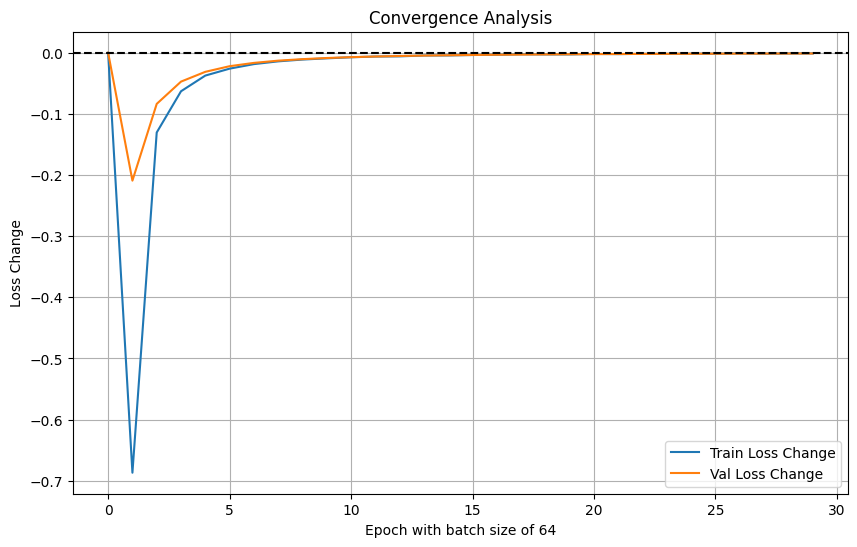

Training with Learning Rate: 0.01, Batch Size: 128
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 1.9398 | Train Acc: 63.79%
  Val Loss: 0.9157 | Val Acc: 75.37%
Epoch 2/30
  Train Loss: 0.6937 | Train Acc: 80.45%
  Val Loss: 0.5252 | Val Acc: 8

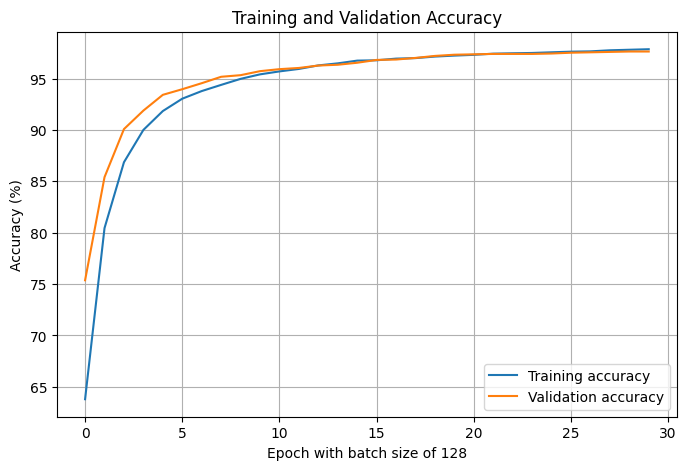

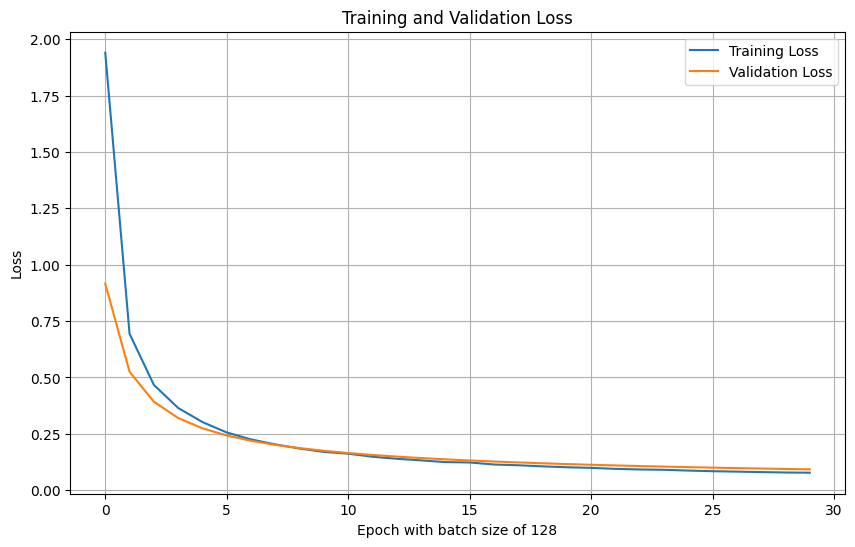

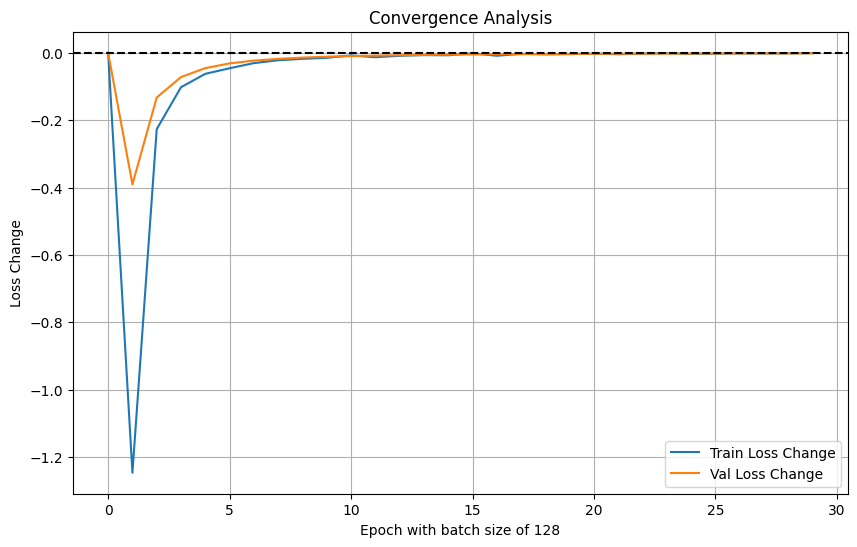

In [13]:
results_bs = []
fixed_learning_rate = 0.01

print("\nTesting different batch sizes with fixed learning rate (0.01):")
best_val_accuracy_bs = 0
best_bs=None

for bs in batch_sizes:
    print(f"Training with Learning Rate: {fixed_learning_rate}, Batch Size: {bs}")

    logisticRegression = Logistic_Regression_from_scratch()
    loader = dl.build_loader(bs)

    logisticRegression.train(fixed_learning_rate, no_epochs, loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'])
    plot_acc(f'with batch size of {bs}')
    plot_loss(f'with batch size of {bs}')
    plot_converge(f'with batch size of {bs}')
    current_best_val_accuracy = max(logisticRegression.validation_accuracies)

    if current_best_val_accuracy > best_val_accuracy_bs:
        best_val_accuracy_bs = current_best_val_accuracy
        best_bs=bs


### calculating the test accuracy for the best batch size

In [14]:
print(f"the best batch size {best_bs}")

logisticRegression = Logistic_Regression_from_scratch()
loader = dl.build_loader(best_bs)
logisticRegression.train(fixed_learning_rate, no_epochs, loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'])
test_model()

the best batch size 16
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.6490 | Train Acc: 87.83%
  Val Loss: 0.1863 | Val Acc: 95.17%
Epoch 2/30
  Train Loss: 0.1182 | Train Acc: 96.75%
  Val Loss: 0.1121 | Val Acc: 97.09%
Epoch 3/30
  Train Los

### combining best learning rate with the best batch size

In [15]:
import time

print(f"the best batch size {best_bs}")
print(f"the best learning rate {best_lr}")
logisticRegression = Logistic_Regression_from_scratch()
loader = dl.build_loader(best_bs)

start_time = time.time()
logisticRegression.train(best_lr, no_epochs, loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'])
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

test_model()

the best batch size 16
the best learning rate 1
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/30
  Train Loss: 0.0315 | Train Acc: 99.38%
  Val Loss: 0.0149 | Val Acc: 99.69%
Epoch 2/30
  Train Loss: 0.0071 | Train Acc: 99.79%
  Val Loss: 0.0137 | Val Acc: 99.6